# 05 · Special paper figures

Three paper figures that do not follow the standard
`train_xgb + plot_contour_2d` pattern of notebooks 01–04. Each has its own logic:

- **Fig 8**: 2D LCDM BAO contour in (Om, H0*rd) — standard pattern but a simple
  LCDM scenario (no w0, wa).
- **Fig 12**: visual comparison of three wCDM contours overlaid (Pantheon+SH0ES,
  Pantheon without SH0ES, DES) — manual overlay, no SHAP.
- **Fig 13**: mu(z) residuals — Pantheon+ binned vs BAO/SN predictions, no ML.


## Index

| Sec. | Figure | Description                                                  |
|------|--------|--------------------------------------------------------------|
| [5.1](#5-1) | **Fig 8**  | LCDM BAO 2D (Om, H0*rd) with DESI            |
| [5.2](#5-2) | **Fig 12** | wCDM with 3 datasets (Pantheon, NoSH0ES, DES) |
| [5.3](#5-3) | **Fig 13** | mu(z) residuals: Pantheon+ binned vs model    |

> Setup is per-section because each figure uses its own data loaders.


## Global setup


In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.ml import use_paper_style
from cosmoml.config import OUTPUTS_DIR

use_paper_style()

NB_NAME = "05_Figures"
DATASETS_DIR = OUTPUTS_DIR / "datasets"
MODELS_DIR   = OUTPUTS_DIR / "models"
FIGURES_DIR  = OUTPUTS_DIR / "figures" / NB_NAME
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False
print(f"Figuras → {FIGURES_DIR}")

Figuras → /home/aleja/CosmoML/outputs/figures/05_Figures


## <a id="5-1"></a>5.1 Fig 8 — LCDM BAO 2D (Om, H0*rd)

**Model:** strict `FlatLambdaCDM` (w0=-1, wa=0 fixed).
**Data:** full DESI BAO DR2.
**Free parameters:** Om and H0*rd (the direct BAO observable).
**Purpose:** simplest LCDM baseline — compare against the §3 notebooks that add
w0, wa. The difference between the LCDM best-fit and the §3 best-fits
quantifies the LCDM vs dynamical dark energy tension.


In [2]:
SECTION = "5_1"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0_rd"]
REF = dict(Om=0.315, H0_rd=67.36 * 147.09)

from cosmoml.data import load_desi_bao
from cosmoml.theory.bao import chi2_bao
from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import train_xgb, plot_contour_2d, plot_learning_curve, shap_summary, shap_waterfall, shap_dependence_all

bao = load_desi_bao()
print(f"DESI BAO: {len(bao)} measurements")

def chi2_fn(Om, H0_rd):
    # Pure LCDM: w0=-1, wa=0 fixed. H0_rd is a single combined parameter.
    return chi2_bao(bao, Om=Om, w0=-1.0, wa=0.0, H0=H0_rd, rd=1.0)

print(f"chi2(LCDM Planck) = {chi2_fn(**REF):.3f}")

DESI BAO: 13 medidas
χ²(LCDM Planck) = 30.681


In [3]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        random_box=dict(Om=(0.20, 0.40), H0_rd=(9000, 10500)),
        n_random=200_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/CosmoML/outputs/datasets/5_1_dataset.csv
min χ² = 10.279


In [4]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)

  cargando modelo cacheado: 5_1_model.ubj
  R²=0.99992 | best_iter=451 | n_train=170,000 | n_val=30,000


  guardado: /home/aleja/CosmoML/outputs/figures/05_Figures/5_1_learning_curve.png


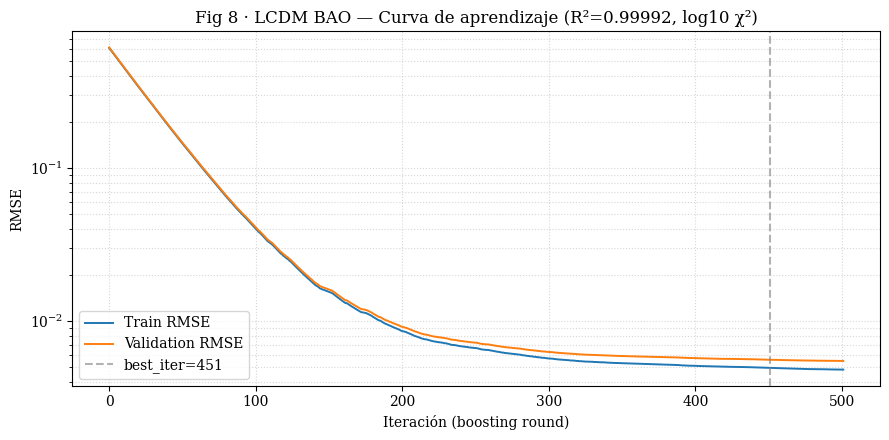

In [5]:
plot_learning_curve(
    info,
    title=f"Fig 8 · LCDM BAO — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

Best-fit ML:    Ω_m=0.2959, H₀·r_d=10167.8
Best-fit teor.: Ω_m=0.2975, H₀·r_d=10152.8
  guardado: /home/aleja/CosmoML/outputs/figures/05_Figures/5_1_Om_H0_rd.png


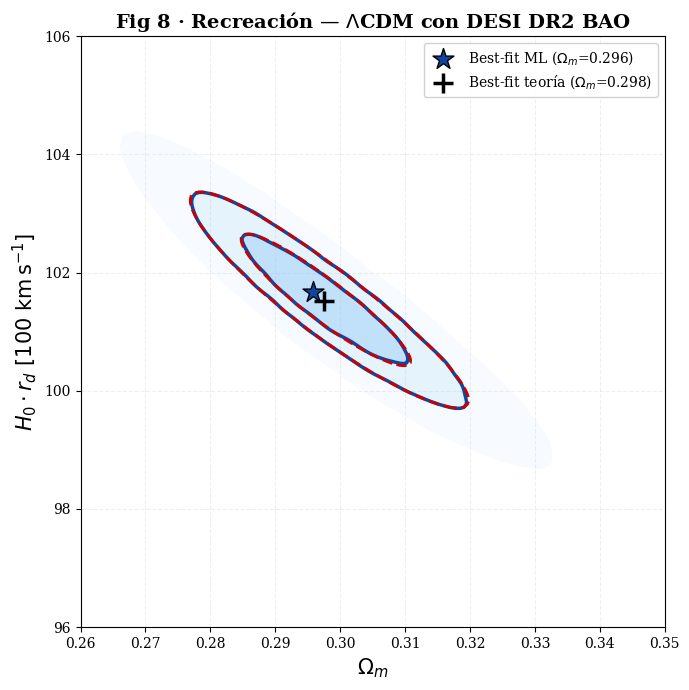

In [6]:
# Fig 8: LCDM contours in (Om, H0*rd).
# Y axis rescaled by /100 (display as 96–106 instead of 9600–10600).
# plot_contour_2d does not support axis rescaling, so we plot manually.

from scipy.ndimage import gaussian_filter

RES = 200
SIGMA = 2.0

# Slightly wider ranges so the full contour fits.
om_range   = np.linspace(0.25, 0.36, RES)
h0rd_range = np.linspace(9600, 10600, RES)
XX, YY = np.meshgrid(om_range, h0rd_range)

# ML prediction
grid = pd.DataFrame({"Om": XX.ravel(), "H0_rd": YY.ravel()})
Z_ML = model.predict(grid).reshape(RES, RES)
delta_ml = gaussian_filter(Z_ML - Z_ML.min(), sigma=SIGMA)

# Theory (only where Delta-chi2_ML < 20 to skip irrelevant regions)
Z_TH = np.full((RES, RES), np.nan)
for i in range(RES):
    for j in range(RES):
        if delta_ml[i, j] < 20:
            Z_TH[i, j] = chi2_fn(float(XX[i, j]), float(YY[i, j]))
valid_th = Z_TH[~np.isnan(Z_TH)]
delta_th = Z_TH - valid_th.min()

# Best-fits
i_ml = np.unravel_index(np.argmin(Z_ML), Z_ML.shape)
i_th = np.unravel_index(np.nanargmin(Z_TH), Z_TH.shape)
bf_ml_om, bf_ml_h0rd = XX[i_ml], YY[i_ml]
bf_th_om, bf_th_h0rd = XX[i_th], YY[i_th]
print(f"Best-fit ML:    Ω_m={bf_ml_om:.4f}, H₀·r_d={bf_ml_h0rd:.1f}")
print(f"Best-fit teor.: Ω_m={bf_th_om:.4f}, H₀·r_d={bf_th_h0rd:.1f}")

# === Plot with Y axis rescaled /100 ===
YY_scaled = YY / 100.0

fig, ax = plt.subplots(figsize=(7, 7))

# ML background (1-sigma and 2-sigma)
ax.contourf(XX, YY_scaled, delta_ml,
            levels=[0, 2.30, 6.18, 15],
            colors=['#bbdefb', '#e3f2fd', '#f7fbff'], alpha=0.9)
ax.contour(XX, YY_scaled, delta_ml, levels=[2.30, 6.18],
           colors='#0d47a1', linewidths=2.5)

# Theory contours overlaid
ax.contour(XX, YY_scaled, delta_th, levels=[2.30, 6.18],
           colors='#cc0000', linewidths=2.0, linestyles='--')

# Best-fits (Y coordinate rescaled)
ax.scatter(bf_ml_om, bf_ml_h0rd / 100.0, marker='*', s=250,
           color='#0d47a1', edgecolors='black',
           label=fr'Best-fit ML ($\Omega_m$={bf_ml_om:.3f})', zorder=10)
ax.scatter(bf_th_om, bf_th_h0rd / 100.0, marker='+', s=200,
           color='black', linewidths=2.5,
           label=fr'Best-fit teoría ($\Omega_m$={bf_th_om:.3f})', zorder=10)

ax.set_xlim(0.26, 0.35)
ax.set_ylim(96, 106)
ax.set_xlabel(r"$\Omega_m$", fontsize=15)
ax.set_ylabel(r"$H_0 \cdot r_d \ [100 \ \mathrm{km \, s^{-1}}]$", fontsize=15)
ax.set_title(r"Fig 8 · Recreación — $\Lambda$CDM con DESI DR2 BAO", fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9, fontsize=10)
ax.grid(alpha=0.2, ls='--')

fig.tight_layout()
plt.show()

  guardado: /home/aleja/CosmoML/outputs/figures/05_Figures/5_1_shap_beeswarm.png


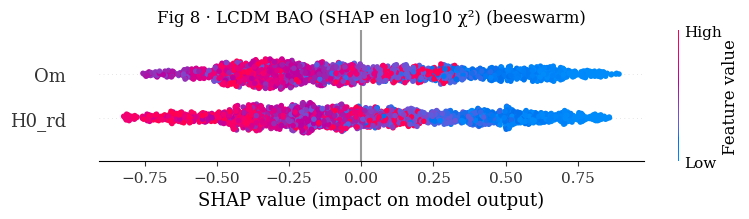

  guardado: /home/aleja/CosmoML/outputs/figures/05_Figures/5_1_shap_bar.png


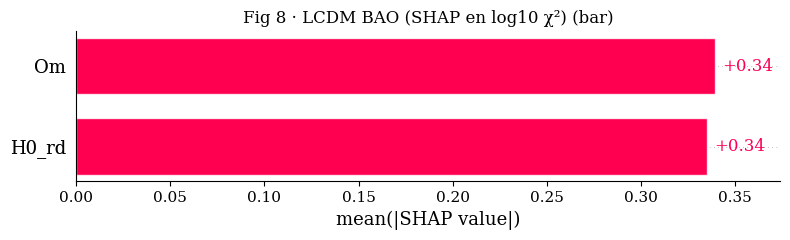

  guardado: /home/aleja/CosmoML/outputs/figures/05_Figures/5_1_shap_waterfall.png


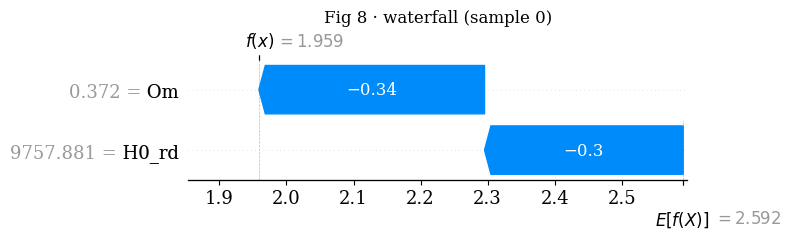

  guardado: /home/aleja/CosmoML/outputs/figures/05_Figures/5_1_shap_Om.png


<Figure size 640x480 with 0 Axes>

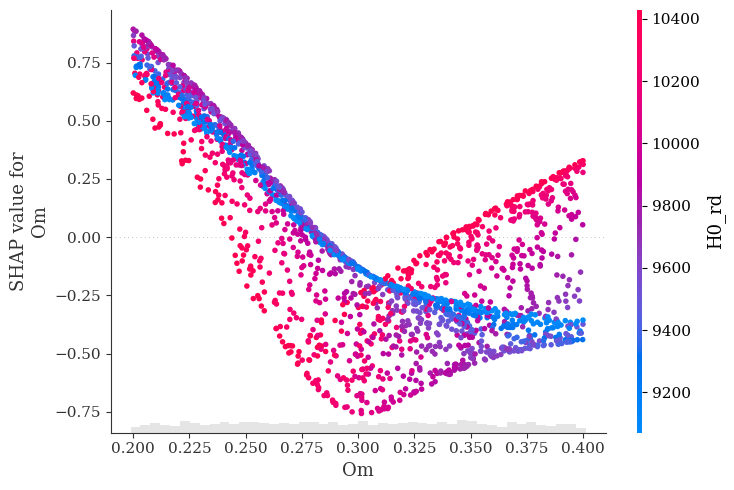

  guardado: /home/aleja/CosmoML/outputs/figures/05_Figures/5_1_shap_H0_rd.png


<Figure size 640x480 with 0 Axes>

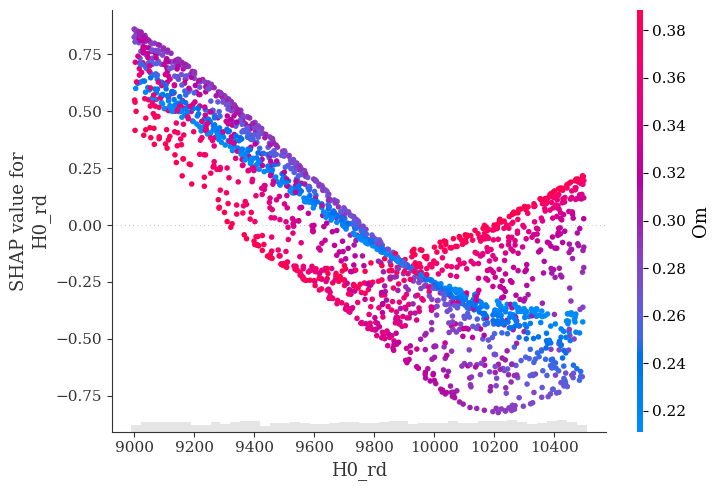

[PosixPath('/home/aleja/CosmoML/outputs/figures/05_Figures/5_1_shap_Om.png'),
 PosixPath('/home/aleja/CosmoML/outputs/figures/05_Figures/5_1_shap_H0_rd.png')]

In [7]:
shap_v, X_s = shap_summary(model, info["X_val"], save_dir=None, prefix=SECTION,
                           title="Fig 8 · LCDM BAO (SHAP in log10 chi2)", show=True)
shap_waterfall(shap_v, idx=0, save_path=None,
               title="Fig 8 · waterfall (sample 0)", show=True)
shap_dependence_all(shap_v, X_s, save_dir=None, prefix=SECTION, show=True)

## <a id="5-2"></a>5.2 Fig 12 — wCDM with Pantheon+SH0ES vs Pantheon no-SH0ES vs DES

**Model:** `FlatwCDM` (Om, w) with H0 = 70 fixed.
**Data:** three independent datasets overlaid on the same plot:
- Pantheon+SH0ES with Cepheids (`use_cepheid_calibrators=True`).
- Pantheon+ without Cepheids (`use_cepheid_calibrators=False`).
- DES SN5YR 2025.

**Result:** the three contours in (Om, w) reveal the tension between datasets.
Pantheon+SH0ES pulls towards w<-1 because of the Cepheid calibration; DES is
closer to Lambda.

This scenario trains three XGBoost models (one per dataset) and overlays them
manually — `plot_contour_2d` only draws one model.


In [8]:
from cosmoml.data import load_pantheon_plus, load_des_2025
from cosmoml.theory.sne import chi2_sne, chi2_sne_des
from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import train_xgb

SECTION = "5_2"
FEATURES = ["Om", "w"]
H0_FIXED = 70.0

# Three datasets to train (one per probe)
configs = [
    dict(name="Panth+SH0ES", suffix="Pantheon",
         loader=lambda: load_pantheon_plus(apply_mask=True),
         chi2=lambda d, Om, w: chi2_sne(d, model="FlatwCDM", Om=Om, H0=H0_FIXED, w0=w,
                                        M="marginalize", use_cepheid_calibrators=True)),
    dict(name="Panth NoSH0ES", suffix="NoSHOES",
         loader=lambda: load_pantheon_plus(apply_mask=True, keep_calibrators=False),
         chi2=lambda d, Om, w: chi2_sne(d, model="FlatwCDM", Om=Om, H0=H0_FIXED, w0=w,
                                        M="marginalize", use_cepheid_calibrators=False)),
    dict(name="DES2025", suffix="DES",
         loader=lambda: load_des_2025(),
         chi2=lambda d, Om, w: chi2_sne_des(d, model="FlatwCDM", Om=Om, H0=H0_FIXED, w0=w)),
]

# Train the 3 models (model caching disabled; retrain each session)
results = {}
for cfg in configs:
    name, suffix = cfg['name'], cfg['suffix']
    print(f"\n=== {name} ===")
    data = cfg['loader']()
    fn = lambda Om, w, _data=data, _f=cfg['chi2']: _f(_data, Om, w)
    csv = DATASETS_DIR / f"{SECTION}_dataset_{suffix}.csv"
    def builder(_fn=fn, _csv=csv):
        return build_chi2_dataset(
            chi2_fn=_fn, param_names=FEATURES,
            random_box=dict(Om=(0.1, 0.5), w=(-2.0, -0.4)),
            n_random=30_000, save_to=_csv, seed=42,
        )
    df = load_or_build(csv, builder, force=False)
    print(f"  min χ² = {df['chi2'].min():.3f}")
    model, info = train_xgb(
        df, features=FEATURES, log_target=True,
        hp_overrides=dict(n_estimators=2000, learning_rate=0.03, max_depth=8),
        cache_path=None,
        force_retrain=FORCE_RETRAIN,
    )
    results[suffix] = dict(name=name, model=model, chi2_fn=fn, df=df)


=== Panth+SH0ES ===
Cargando dataset existente: /home/aleja/CosmoML/outputs/datasets/5_2_dataset_Pantheon.csv
  min χ² = 1463.437
  cargando modelo cacheado: 5_2_model_Pantheon.ubj
  R²=0.99988 | best_iter=237 | n_train=25,500 | n_val=4,500

=== Panth NoSH0ES ===
Cargando dataset existente: /home/aleja/CosmoML/outputs/datasets/5_2_dataset_NoSHOES.csv
  min χ² = 1402.471
  cargando modelo cacheado: 5_2_model_NoSHOES.ubj
  R²=0.99986 | best_iter=226 | n_train=25,500 | n_val=4,500

=== DES2025 ===
Cargando dataset existente: /home/aleja/CosmoML/outputs/datasets/5_2_dataset_DES.csv
  min χ² = 1639.032
  cargando modelo cacheado: 5_2_model_DES.ubj
  R²=0.99985 | best_iter=208 | n_train=25,500 | n_val=4,500


  guardado: /home/aleja/CosmoML/outputs/figures/05_Figures/5_2_Om_w_overlay.png


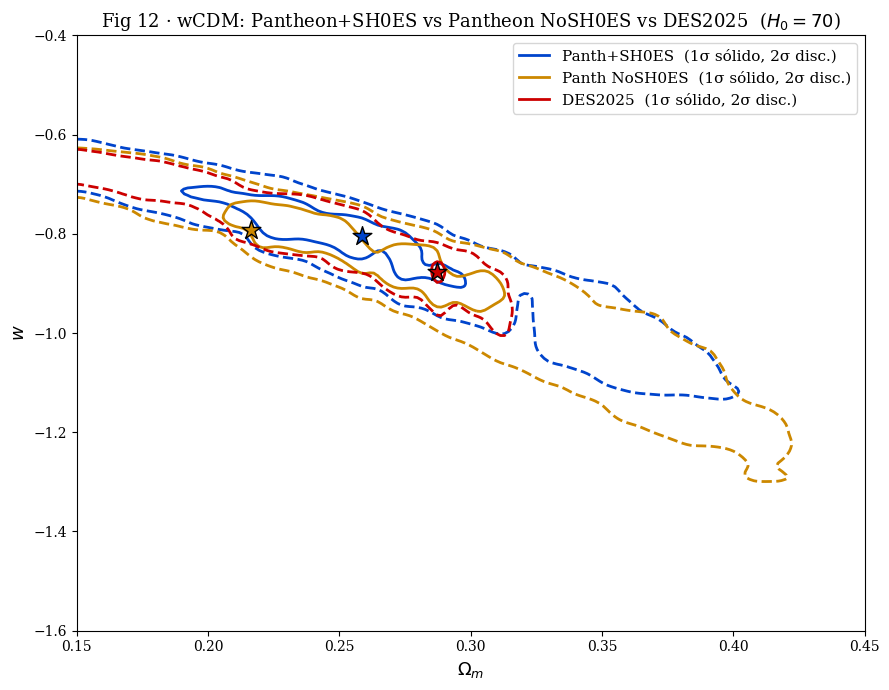

In [9]:
# Manually overlay the 3 contours on a single plot
RES = 200
SIGMA = 2.0
x_range = (0.15, 0.45)
y_range = (-1.6, -0.4)

xs = np.linspace(*x_range, RES)
ys = np.linspace(*y_range, RES)
XX, YY = np.meshgrid(xs, ys)
grid = pd.DataFrame({"Om": XX.ravel(), "w": YY.ravel()})

# ML predictions per dataset
deltas = {}
for suffix, r in results.items():
    Z = r['model'].predict(grid).reshape(RES, RES)
    deltas[suffix] = gaussian_filter(Z - Z.min(), sigma=SIGMA)

# Plot
COLORS = {"Pantheon": "#0044cc", "NoSHOES": "#cc8800", "DES": "#cc0000"}
fig, ax = plt.subplots(figsize=(9, 7))
for suffix, d in deltas.items():
    cs = ax.contour(XX, YY, d, levels=[2.30, 6.18],
                    colors=COLORS[suffix], linewidths=2.0, linestyles=['-', '--'])
    # Best-fit (star marker)
    Z_raw = results[suffix]['model'].predict(grid).reshape(RES, RES)
    i_min = np.unravel_index(np.argmin(Z_raw), Z_raw.shape)
    ax.scatter(xs[i_min[1]], ys[i_min[0]], s=200, marker='*',
               color=COLORS[suffix], edgecolors='black', zorder=10)

# Manual legend (omit best-fit markers to reduce clutter)
import matplotlib.lines as mlines
handles = [mlines.Line2D([], [], color=COLORS[s], linewidth=2,
                          label=f"{results[s]['name']}  (1σ sólido, 2σ disc.)")
           for s in results]
ax.legend(handles=handles, loc='upper right', fontsize=11)
ax.set_xlim(*x_range); ax.set_ylim(*y_range)
ax.set_xlabel(r"$\Omega_m$", fontsize=13)
ax.set_ylabel(r"$w$", fontsize=13)
ax.set_title("Fig 12 · wCDM: Pantheon+SH0ES vs Pantheon NoSH0ES vs DES2025  ($H_0=70$)",
             fontsize=13)
fig.tight_layout()
plt.show()

## <a id="5-3"></a>5.3 Fig 13 — mu(z) residuals: Pantheon+ binned vs model

**Data:** Pantheon+SH0ES (binned in 15 z bins) and DESI BAO (only DM/rd
measurements).
**Model:** `Flatw0waCDM` with two baselines:
- BAO best-fit (Om=0.2975, w0=-0.827)
- Pantheon+ SNe best-fit (Om=0.334)

**No ML.** Pure residual plot: mu(z) - mu_LCDM_baseline per data point +
theory curves. Useful for visualizing the redshift "wiggle" that motivates
the CPL parametrization.


In [10]:
SECTION = "5_3"

import scipy.integrate as integrate
from cosmoml.config import C_LIGHT, PLANCK_H0, PLANCK_RD, DATA_DIR

H0_FID = PLANCK_H0
RD_FID = PLANCK_RD

def E_func(z, Om, w0, wa):
    f_de = (1 + z) ** (3 * (1 + w0 + wa)) * np.exp(-3 * wa * z / (1 + z))
    return np.sqrt(Om * (1 + z) ** 3 + (1 - Om) * f_de)

def DM_func(z, Om, w0, wa):
    if z == 0:
        return 0.0
    integral, _ = integrate.quad(lambda zp: 1.0 / E_func(zp, Om, w0, wa), 0, z)
    return (C_LIGHT / H0_FID) * integral

def mu_theory(z, Om, w0, wa):
    return 5 * np.log10(np.maximum((1 + z) * DM_func(z, Om, w0, wa), 1e-10)) + 25

# Best-fit values from notebooks 01 (SNe) and 03 (BAO)
Om_bao_bf, w0_bao_bf, wa_bao_bf = 0.2975, -0.827, 0.0   # baseline BAO LCDM-like
Om_sn_bf,  w0_sn_bf,  wa_sn_bf  = 0.334, -1.0,    0.0   # baseline SNe LCDM

In [11]:
# === BAO ===
bao_path = DATA_DIR / "desi_bao" / "desi_gaussian_bao_ALL_GCcomb_mean.txt"
cov_path = DATA_DIR / "desi_bao" / "desi_gaussian_bao_ALL_GCcomb_cov.txt"
bao_df = pd.read_csv(bao_path, sep=r"\s+", comment="#", header=None, names=["z","val","type"])
mask_dm = bao_df["type"].str.contains("DM")
z_bao = bao_df["z"][mask_dm].values
dm_rd_obs = bao_df["val"][mask_dm].values
dm_rd_err = np.sqrt(np.diag(np.loadtxt(cov_path)))[mask_dm.values]
print(f"BAO: {len(z_bao)} DM/r_d measurements at z={z_bao}")

# === Pantheon+ binned residuals (15 log bins) ===
sn_path = DATA_DIR / "pantheon" / "Pantheon+SH0ES.dat"
sn_cov_path = DATA_DIR / "pantheon" / "Pantheon+SH0ES_STAT+SYS.cov"
sn_df = pd.read_csv(sn_path, sep=r"\s+")
err_sn_all = np.sqrt(np.diag(np.genfromtxt(sn_cov_path, skip_header=1).reshape(1701, 1701)))
z_bins = np.geomspace(sn_df["zHD"].min(), sn_df["zHD"].max(), 16)
zb_l, mb_l, eb_l = [], [], []
for i in range(15):
    idx = (sn_df["zHD"] >= z_bins[i]) & (sn_df["zHD"] < z_bins[i+1])
    if idx.any():
        w = 1.0 / err_sn_all[idx.values] ** 2
        zb_l.append(np.average(sn_df["zHD"][idx], weights=w))
        mb_l.append(np.average(sn_df["m_b_corr"][idx], weights=w))
        eb_l.append(1.0 / np.sqrt(np.sum(w)))

zb = np.array(zb_l); mb = np.array(mb_l); eb = np.array(eb_l)
print(f"SNe: {len(zb)} log bins at z=[{zb[0]:.4f}, {zb[-1]:.3f}]")

# BAO best-fit w0 (used for CPL theory curves)
w0_best = -0.827

BAO: 6 medidas DM/r_d en z=[0.51  0.706 0.934 1.321 1.484 2.33 ]
SNe: 15 bins logarítmicos en z=[0.0012, 1.636]


  guardado: /home/aleja/CosmoML/outputs/figures/05_Figures/5_3_residuos_cruzados.png


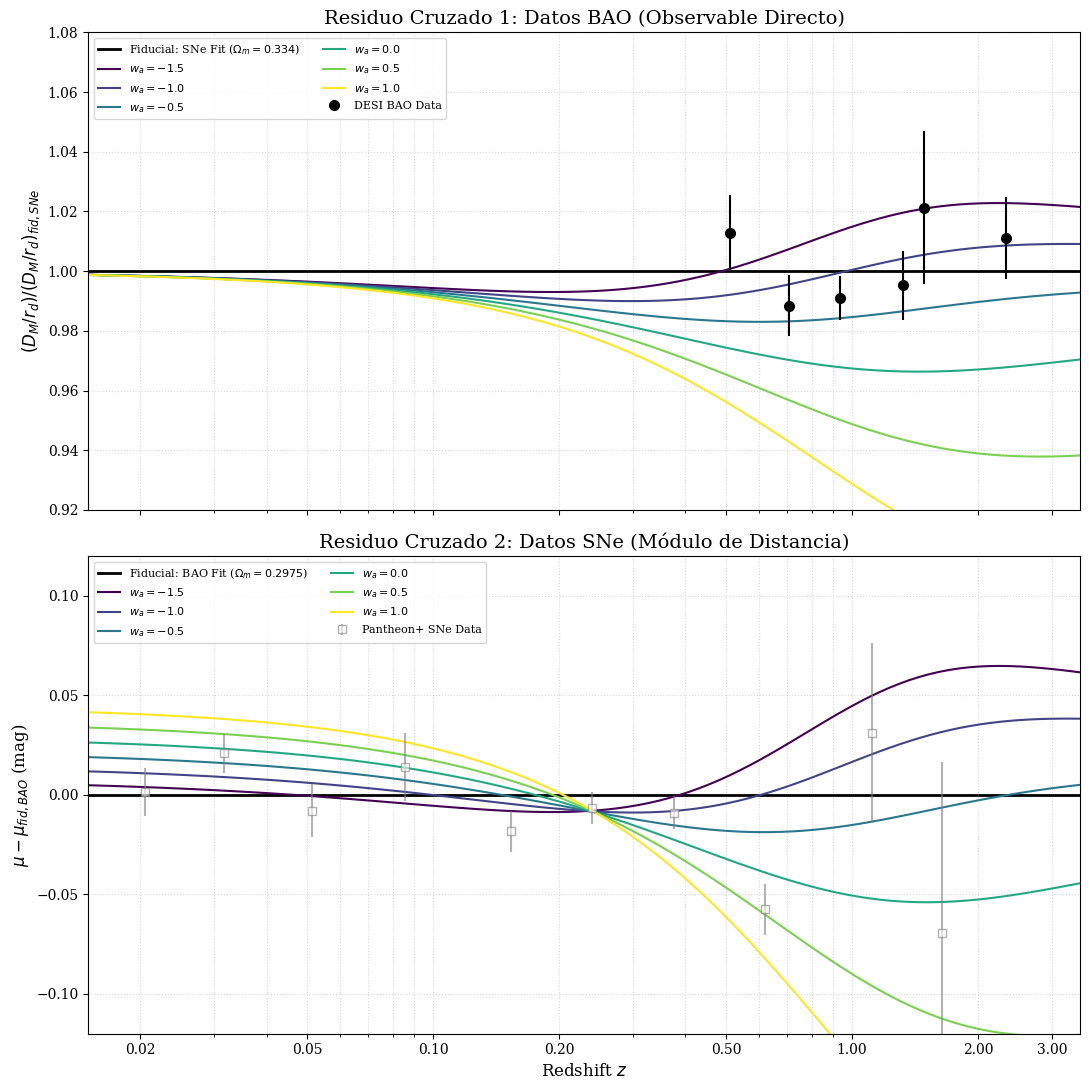

In [12]:
# Fig 13: cross-comparison of BAO and SNe residuals for wa in {-1.5,-1,-0.5,0,0.5,1}.
# Panel 1: DM/r_d ratio relative to the SNe LCDM fiducial (Om=0.334).
# Panel 2: SNe Delta-mu relative to the BAO LCDM fiducial (Om=0.2975),
#   with M re-calibrated per bin (weighted average for each wa).


import matplotlib.ticker as ticker

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 11), sharex=True)
z_plot = np.geomspace(0.015, 3.5, 100)

wa_values = [-1.5, -1.0, -0.5, 0.0, 0.5, 1.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(wa_values)))

# --- PANEL 1: BAO (DM/r_d) relative to SNe fiducial (Om=0.334) ---
ax1.axhline(1.0, color='black', lw=2, label=fr'Fiducial: SNe Fit ($\Omega_m={Om_sn_bf}$)')
dm_rd_fid_line = np.array([DM_func(z, Om_sn_bf, -1.0, 0.0) / RD_FID for z in z_plot])
dm_rd_fid_pts  = np.array([DM_func(z, Om_sn_bf, -1.0, 0.0) / RD_FID for z in z_bao])

for wa, col in zip(wa_values, colors):
    dm_rd_line = np.array([DM_func(z, Om_sn_bf, w0_best, wa) / RD_FID for z in z_plot])
    ax1.plot(z_plot, dm_rd_line / dm_rd_fid_line, color=col, lw=1.5, label=f'$w_a={wa}$')

ax1.errorbar(z_bao, dm_rd_obs / dm_rd_fid_pts, yerr=dm_rd_err / dm_rd_fid_pts,
             fmt='o', color='black', markersize=7, label='DESI BAO Data')
ax1.set_ylabel(r'$(D_M/r_d) / (D_M/r_d)_{fid, SNe}$', fontsize=12)
ax1.set_ylim(0.92, 1.08)
ax1.set_title('Cross-residual 1: BAO data (direct observable)', fontsize=14)

# --- PANEL 2: SNe Delta-mu relative to BAO fiducial (Om=0.2975) ---
ax2.axhline(0, color='black', lw=2, label=fr'Fiducial: BAO Fit ($\Omega_m={Om_bao_bf}$)')

mu_fid_bao_sn = np.array([mu_theory(z, Om_bao_bf, -1.0, 0.0) for z in zb])
off_fid = np.average(mb - mu_fid_bao_sn, weights=1.0 / eb ** 2)

for wa, col in zip(wa_values, colors):
    # Re-calibrate M per bin: weighted average over SNe
    mu_bin = np.array([mu_theory(z, Om_bao_bf, w0_best, wa) for z in zb])
    off_m = np.average(mb - mu_bin, weights=1.0 / eb ** 2)

    mu_line     = np.array([mu_theory(z, Om_bao_bf, w0_best, wa) for z in z_plot]) + off_m
    mu_fid_line = np.array([mu_theory(z, Om_bao_bf, -1.0,    0.0) for z in z_plot]) + off_fid
    ax2.plot(z_plot, mu_line - mu_fid_line, color=col, lw=1.5, label=f'$w_a={wa}$')

ax2.errorbar(zb, (mb - off_fid) - mu_fid_bao_sn, yerr=eb,
             fmt='s', mfc='white', mec='gray', ecolor='gray', alpha=0.6,
             label='Pantheon+ SNe Data')
ax2.set_ylabel(r'$\mu - \mu_{fid, BAO}$ (mag)', fontsize=12)
ax2.set_ylim(-0.12, 0.12)
ax2.set_title('Cross-residual 2: SNe data (distance modulus)', fontsize=14)

# Common axis formatting
for ax in (ax1, ax2):
    ax.set_xscale('log')
    ax.set_xlim(0.015, 3.5)
    ax.grid(True, which='both', ls=':', alpha=0.5)
    ax.legend(fontsize=8, loc='upper left', ncol=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_xticks([0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 3.0])

ax2.set_xlabel('Redshift $z$', fontsize=12)
fig.tight_layout()
plt.show()

## <a id="5-4"></a>5.4 — ML test: ¿Es CPL una buena aproximación al modelo Taylor de 4º orden?
(paper arXiv:2506.13537)

**w(a) = w₀ + wₐ(1−a) + (1/2)w_b(1−a)² + (1/6)w_c(1−a)³**   [con a = 1/(1+z)]

Los factores 1/2 y 1/6 son los coeficientes explícitos del desarrollo de Taylor (no absorbidos en los parámetros w_b, w_c).

**Pipeline:**
1. Construir dataset 6D (Ωm, H₀, w₀, wₐ, w_b, w_c) usando χ² BAO DESI DR2
2. Entrenar XGBoost surrogate
3. SHAP: comprobar si importancia w_b, w_c ≪ w₀, wₐ  →  CPL es suficiente
4. MCMC + GetDist: marginales de w_b, w_c compatibles con 0  →  datos no distinguen orden superior
5. Overlay (w₀, wₐ): contornos CPL vs Taylor 4º orden se solapan

In [ ]:
from scipy.integrate import cumulative_trapezoid
from iminuit import Minuit
import getdist, getdist.plots

from cosmoml.data import load_desi_bao
from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import (
    train_xgb, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all, plot_corner_marginal,
)
from cosmoml.config import C_LIGHT, PLANCK_RD

SECTION_54  = "5_4"
FEATURES_6D = ["Om", "H0", "w0", "wa", "wb", "wc"]
LABELS_6D   = {
    "Om": r"$\Omega_m$", "H0": r"$H_0$",
    "w0": r"$w_0$",     "wa": r"$w_a$",
    "wb": r"$w_b$",     "wc": r"$w_c$",
}
MARKERS_6D  = {"w0": -1.0, "wa": 0.0, "wb": 0.0, "wc": 0.0}
RANGES_6D   = dict(
    Om=(0.1, 0.9), H0=(20., 100.),
    w0=(-3., 0.2), wa=(-3., 2.),
    wb=(-3., 3.),  wc=(-3., 3.),
)

CHAINS_DIR_54 = OUTPUTS_DIR / "chains" / "05_Figures"
CHAINS_DIR_54.mkdir(parents=True, exist_ok=True)

bao_t4 = load_desi_bao()
print(f"DESI BAO: {len(bao_t4)} measurements")

In [ ]:
_CHI2_BAD_T4 = 99999.0
_N_GRID_T4   = 500


def _taylor4_theory_vector(bao_data, Om, H0, w0, wa, wb, wc, rd=PLANCK_RD):
    """BAO theory vector for w(a) = w0 + wa*(1-a) + (1/2)*wb*(1-a)^2 + (1/6)*wc*(1-a)^3.
    Pre-computes f_de and D_M on a fine z-grid; then interpolates to data redshifts."""
    z_max = float(np.max(bao_data.unique_z)) * 1.05
    z_g   = np.linspace(0.0, z_max, _N_GRID_T4)
    x_g   = z_g / (1.0 + z_g)                       # x = 1 - a = z/(1+z)
    w_g   = w0 + wa*x_g + 0.5*wb*x_g**2 + (1.0/6.0)*wc*x_g**3
    intgd = (1.0 + w_g) / (1.0 + z_g)
    f_de  = np.exp(3.0 * cumulative_trapezoid(intgd, z_g, initial=0.0))
    E_g   = np.sqrt(Om*(1 + z_g)**3 + (1 - Om)*f_de)
    dm_g  = cumulative_trapezoid(C_LIGHT / (H0 * E_g), z_g, initial=0.0)

    out = np.empty(len(bao_data))
    for i in range(len(bao_data)):
        z   = bao_data.z[i]
        q   = str(bao_data.type[i]).upper()
        E_z = float(np.interp(z, z_g, E_g))
        dm  = float(np.interp(z, z_g, dm_g))
        dh  = C_LIGHT / (H0 * E_z)
        if   "DM" in q: out[i] = dm / rd
        elif "DH" in q: out[i] = dh / rd
        elif "DV" in q: out[i] = (z * dm**2 * dh)**(1.0/3.0) / rd
        else:            out[i] = np.nan
    return out


def chi2_bao_taylor4(Om, H0, w0, wa, wb, wc):
    """χ² BAO for the 4th-order Taylor w(a) parametrization. Module-level → picklable."""
    if not (0.0 < Om < 1.0) or H0 <= 0:
        return _CHI2_BAD_T4
    try:
        th   = _taylor4_theory_vector(bao_t4, Om, H0, w0, wa, wb, wc)
        diff = bao_t4.val - th
        return float(diff @ bao_t4.inv_cov @ diff)
    except Exception:
        return _CHI2_BAD_T4


# Quick sanity check: wb=wc=0 should match CPL chi2
from cosmoml.theory import chi2_bao as _chi2_bao_cpl
_v_t4  = chi2_bao_taylor4(0.30, 67.36, -1.0, 0.0, 0.0, 0.0)
_v_cpl = _chi2_bao_cpl(bao_t4, Om=0.30, w0=-1.0, wa=0.0, H0=67.36)
print(f"Taylor4 (wb=wc=0): {_v_t4:.4f}   CPL: {_v_cpl:.4f}   diff: {abs(_v_t4-_v_cpl):.2e}")

In [ ]:
CSV_54 = DATASETS_DIR / f"{SECTION_54}_dataset.csv"

print("Locating best-fit with Minuit (6D)...")
_m54 = Minuit(chi2_bao_taylor4,
              Om=0.30, H0=68.0, w0=-1.0, wa=0.0, wb=0.0, wc=0.0)
_m54.limits = [(0.1, 0.9), (20, 100), (-3, 0.2), (-3, 2), (-3, 3), (-3, 3)]
_m54.migrad()
REF_54 = {f: float(_m54.values[f]) for f in FEATURES_6D}
print(f"Best-fit : {REF_54}")
print(f"chi2_min : {_m54.fval:.2f}")


def builder_54():
    slices = []
    for _i, fi in enumerate(FEATURES_6D):
        for fj in FEATURES_6D[_i + 1:]:
            fixed = {f: REF_54[f] for f in FEATURES_6D if f not in (fi, fj)}
            slices.append({fi: RANGES_6D[fi], fj: RANGES_6D[fj], **fixed, "_n": 3_000})
    return build_chi2_dataset(
        chi2_fn=chi2_bao_taylor4, param_names=FEATURES_6D,
        slices=slices,
        random_box={f: RANGES_6D[f] for f in FEATURES_6D},
        n_random=20_000, save_to=CSV_54, seed=42,
    )


df_54 = load_or_build(CSV_54, builder_54, force=False)
print(f"Dataset : {len(df_54):,} rows | chi2 min = {df_54['chi2'].min():.3f}")

In [ ]:
model_54, info_54 = train_xgb(
    df_54, features=FEATURES_6D, log_target=True,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION_54}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info_54,
    title=f"\u00a75.4 Taylor w(a) 4\u00ba orden \u2014 Learning Curve (R\u00b2={info_54['r2']:.5f})",
    show=True,
)

In [ ]:
shap_v_54, X_s_54 = shap_summary(
    model_54, info_54["X_val"],
    title="§5.4 Taylor 4º orden — SHAP (log\u2081\u2080 \u03c7\u00b2)",
    show=True,
)
shap_waterfall(shap_v_54, idx=0,
               title="§5.4 Taylor 4º orden — SHAP waterfall", show=True)
shap_dependence_all(shap_v_54, X_s_54, show=True)
# Key result: if SHAP(wb) and SHAP(wc) << SHAP(w0, wa) -> CPL is sufficient

In [ ]:
_chain_path_54  = CHAINS_DIR_54 / f"{SECTION_54}_samples.npy"
_str_labels_54  = [LABELS_6D[f].replace("$", "") for f in FEATURES_6D]

if _chain_path_54.exists() and not FORCE_RETRAIN:
    samples_54 = np.load(_chain_path_54)
    print(f"Loaded chain: {len(samples_54):,} samples")
    mc_54 = getdist.MCSamples(
        samples=samples_54, names=FEATURES_6D, labels=_str_labels_54,
        settings={"smooth_scale_2D": 0.5, "smooth_scale_1D": 0.5},
    )
    g = getdist.plots.get_subplot_plotter()
    g.triangle_plot(mc_54, filled=True, contour_colors=["#0044cc"],
                    markers=MARKERS_6D,
                    marker_args={"ls": "--", "color": "gray", "lw": 1.5, "alpha": 0.8})
    g.fig.suptitle("§5.4 — w\u2080w\u2090w_bw_c \u00b7 DESI BAO", fontsize=12, y=1.01)
    plt.show()
else:
    samples_54 = plot_corner_marginal(
        model_54, FEATURES_6D, RANGES_6D,
        labels=LABELS_6D, ref=REF_54, markers=MARKERS_6D,
        title="§5.4 — w\u2080w\u2090w_bw_c \u00b7 DESI BAO",
        n_chains=512, n_steps=5_000, burn_in=400, ess_target=5_000,
        smooth_scale=0.5, show=True,
    )
    np.save(_chain_path_54, samples_54)
    print(f"Chain saved: {_chain_path_54}")

In [ ]:
# --- Marginal constraints on the 6 parameters from the ML posterior ---
_med_p  = np.median(samples_54, axis=0)
_lo1_p  = np.percentile(samples_54, 16, axis=0)
_hi1_p  = np.percentile(samples_54, 84, axis=0)

print(f"{'Parameter':<12} {'median':>10}  {'  +1sigma':>10}  {'  -1sigma':>10}")
print("-" * 50)
for f, med, lo, hi in zip(FEATURES_6D, _med_p, _lo1_p, _hi1_p):
    print(f"{f:<12} {med:>10.4f}  {hi - med:>+10.4f}  {lo - med:>+10.4f}")

In [ ]:
_i_w0 = FEATURES_6D.index("w0")
_i_wa = FEATURES_6D.index("wa")
samples_w0wa_t4 = samples_54[:, [_i_w0, _i_wa]]

_cpl_chain = OUTPUTS_DIR / "chains" / "06_Paper" / "6_2_1a_samples.npy"
FEATS_CPL  = ["w0", "wa"]
LABELS_CPL = {f: LABELS_6D[f] for f in FEATS_CPL}
_str_l     = [LABELS_CPL[f].replace("$", "") for f in FEATS_CPL]

mc_t4 = getdist.MCSamples(
    samples=samples_w0wa_t4, names=FEATS_CPL, labels=_str_l,
    label="Taylor 4\u00ba orden",
    settings={"smooth_scale_2D": 0.5, "smooth_scale_1D": 0.5},
)

if _cpl_chain.exists():
    samples_cpl = np.load(_cpl_chain)[:, [2, 3]]  # columns w0, wa from 4D chain
    mc_cpl = getdist.MCSamples(
        samples=samples_cpl, names=FEATS_CPL, labels=_str_l,
        label="CPL (w\u2080w\u2090)",
        settings={"smooth_scale_2D": 0.5, "smooth_scale_1D": 0.5},
    )
    g = getdist.plots.get_subplot_plotter()
    g.triangle_plot(
        [mc_t4, mc_cpl], filled=True,
        contour_colors=["#0044cc", "#cc0000"],
        legend_labels=["Taylor 4\u00ba orden", "CPL"],
        markers={"w0": -1.0, "wa": 0.0},
        marker_args={"ls": "--", "color": "gray", "lw": 1.5, "alpha": 0.8},
    )
    g.fig.suptitle(
        "§5.4 — Comparaci\u00f3n (w\u2080, w\u2090): CPL vs Taylor 4\u00ba orden", y=1.01
    )
    plt.show()
else:
    print("Chains CPL (06_Paper §2.1a) not found — run notebook 06 first.")
    print("Showing only the Taylor 6D projection onto (w0, wa):")
    g = getdist.plots.get_subplot_plotter()
    g.triangle_plot(mc_t4, filled=True, contour_colors=["#0044cc"],
                    markers={"w0": -1.0, "wa": 0.0})
    g.fig.suptitle(
        "§5.4 — Proyecci\u00f3n (w\u2080, w\u2090) del modelo Taylor 4\u00ba orden", y=1.01
    )
    plt.show()

In [ ]:
# --- Propagate ML posterior samples through the Taylor 4th-order theory ---
_N_PROP = min(2000, len(samples_54))
_rng54  = np.random.default_rng(42)
_idx_p  = _rng54.choice(len(samples_54), _N_PROP, replace=False)

print(f"Propagating {_N_PROP} posterior samples through theory...")
_th_mat = np.array([
    _taylor4_theory_vector(bao_t4, *samples_54[i])
    for i in _idx_p
])  # shape (N_PROP, N_measurements)
print("Done.")

_th_med  = np.median(_th_mat, axis=0)
_th_lo1  = np.percentile(_th_mat, 16,  axis=0)
_th_hi1  = np.percentile(_th_mat, 84,  axis=0)
_th_lo2  = np.percentile(_th_mat,  2.5, axis=0)
_th_hi2  = np.percentile(_th_mat, 97.5, axis=0)
_err_obs = np.sqrt(np.diag(bao_t4.cov))

# Ratio space: every observable type shares the same y-axis centered at 1
_ratio   = bao_t4.val / _th_med          # d_obs / d_model
_ratio_e = _err_obs   / _th_med          # observational sigma in ratio units
_lo1_r   = _th_lo1   / _th_med           # 1-sigma lower band (ratio)
_hi1_r   = _th_hi1   / _th_med
_lo2_r   = _th_lo2   / _th_med           # 2-sigma lower band (ratio)
_hi2_r   = _th_hi2   / _th_med

_resid   = (bao_t4.val - _th_med) / _err_obs          # normalized residuals
_m_err54 = (_th_hi1 - _th_lo1) / (2.0 * _err_obs)    # model 1-sigma in sigma_obs units

_types_s = np.array([str(t) for t in bao_t4.type])
_sty54   = {
    "DM_over_rs": dict(color="#2255cc", marker="o", label=r"$D_M/r_d$"),
    "DH_over_rs": dict(color="#cc3300", marker="s", label=r"$D_H/r_d$"),
    "DV_over_rs": dict(color="#009955", marker="^", label=r"$D_V/r_d$"),
}

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ax1.axhline(1.0, color="gray", lw=1.2, ls="--", alpha=0.7, label="Model median")

for typ, sty in _sty54.items():
    mask = _types_s == typ
    if not mask.any():
        continue
    z_t  = bao_t4.z[mask]
    _ord = np.argsort(z_t)
    z_t  = z_t[_ord]
    r_t  = _ratio[mask][_ord];   re_t = _ratio_e[mask][_ord]
    lo1  = _lo1_r[mask][_ord];   hi1  = _hi1_r[mask][_ord]
    lo2  = _lo2_r[mask][_ord];   hi2  = _hi2_r[mask][_ord]
    res  = _resid[mask][_ord];   me   = _m_err54[mask][_ord]

    ax1.fill_between(z_t, lo2, hi2, color=sty["color"], alpha=0.12)
    ax1.fill_between(z_t, lo1, hi1, color=sty["color"], alpha=0.30)
    ax1.errorbar(z_t, r_t, yerr=re_t, fmt=sty["marker"],
                 color=sty["color"], ms=8, capsize=4, label=sty["label"])

    ax2.errorbar(z_t, res, yerr=me, fmt=sty["marker"],
                 color=sty["color"], ms=7, capsize=3)

ax1.set_ylabel(r"$d_{\rm obs}\,/\,d_{\rm model}$", fontsize=12)
ax1.set_title(
    r"\S5.4 \u2014 Taylor $w(a)$ 4\u00ba orden: DESI BAO datos vs predicci\u00f3n ML"
    "\n"
    r"Bandas: 1\u03c3 (oscuro) y 2\u03c3 (claro) del posterior ML",
    fontsize=11,
)
ax1.legend(fontsize=10)
ax1.grid(True, ls=":", alpha=0.4)
ax1.set_ylim(0.93, 1.07)

ax2.axhline(0, color="black", lw=1.5, ls="--")
ax2.axhspan(-1, 1, alpha=0.12, color="gray", label=r"$\pm1\sigma_{\rm obs}$")
ax2.axhspan(-2, 2, alpha=0.06, color="gray", label=r"$\pm2\sigma_{\rm obs}$")
ax2.set_xlabel("Redshift $z$", fontsize=12)
ax2.set_ylabel(
    r"$(d_{\rm obs} - d_{\rm mod})\,/\,\sigma_{\rm obs}$", fontsize=12
)
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(True, ls=":", alpha=0.4)
ax2.set_ylim(-3.5, 3.5)

fig.tight_layout()
plt.show()
# --- Print table: central values + ML errors for each measurement ---
_type_short = {
    "DM_over_rs": "DM/rd",
    "DH_over_rs": "DH/rd",
    "DV_over_rs": "DV/rd",
}
print()
print(f"{'Type':<10} {'z':>6}  {'d_obs':>8}  {'sigma_obs':>9}  "
      f"{'d_model':>8}  {'+1s':>7}  {'-1s':>7}  {'residual':>9}")
print("-" * 80)
_order_all = np.argsort(bao_t4.z)
for i in _order_all:
    typ  = str(bao_t4.type[i])
    z_i  = bao_t4.z[i]
    d_i  = bao_t4.val[i]
    se_i = _err_obs[i]
    md_i = _th_med[i]
    p1_i = _th_hi1[i] - md_i
    m1_i = md_i - _th_lo1[i]
    rs_i = _resid[i]
    print(f"{_type_short[typ]:<10} {z_i:>6.3f}  {d_i:>8.4f}  "
          f"{se_i:>9.4f}  {md_i:>8.4f}  {p1_i:>+7.4f}  {-m1_i:>+7.4f}  "
          f"{rs_i:>+9.3f} sigma")
print()
_chi2_bf = float(np.sum(_resid**2))
_ndof    = len(bao_t4) - len(FEATURES_6D)
print(f"chi2 (best-fit) = {_chi2_bf:.2f}   ndof = {_ndof}   chi2/ndof = {_chi2_bf/_ndof:.3f}")
